# Airline Customer Satisfaction Prediction

**Goal:** predict whether an airline passenger is *satisfied* or *neutral/dissatisfied* from their flight details and service ratings.

**Dataset:** `train.csv` (103,904 passengers) for training, `test.csv` (25,976 passengers) as the final holdout.

## Contents
1. Load data and preview
2. Data overview
3. Exploratory analysis and visualizations
4. Five key insights
5. Data cleaning and missing values
6. Feature engineering and encoding
7. Model training
8. Model comparison
9. Best model: confusion matrix
10. Save the model

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 1. Load data and preview

In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (103904, 25)
Test:  (25976, 25)


In [4]:
train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Data overview

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


In [11]:
miss = train.isna().sum()
miss = miss[miss > 0].to_frame("missing")
miss["missing_%"] = (miss["missing"] / len(train) * 100).round(2)
display(miss.style.background_gradient(cmap="Reds"))
print(f"Duplicate rows: {train.duplicated().sum()}")

,missing,missing_%
Arrival Delay in Minutes,310,0.300000


Duplicate rows: 0


In [13]:
counts = train["satisfaction"].value_counts()
pct = (counts / counts.sum() * 100).round(1)
display(pd.DataFrame({"count": counts, "%": pct}).style.format({"count": "{:,}", "%": "{:.1f}%"}))


,count,%
satisfaction,,
neutral or dissatisfied,"58,879",56.7%
satisfied,"45,025",43.3%


**Observation:** The target is fairly balanced (56.7% neutral/dissatisfied vs 43.3% satisfied), so no resampling is needed. A majority-class baseline would score 56.7% accuracy, so models are judged against that, using precision, recall, F1 and ROC-AUC alongside accuracy.

In [14]:
target = "satisfaction"
drop_cols = ["Unnamed: 0", "id"]

features = train.drop(columns=drop_cols + [target])
cat_cols = features.select_dtypes(exclude="number").columns.tolist()
rating_cols = [
    c for c in features.select_dtypes("number").columns
    if features[c].dropna().between(0, 5).all() and features[c].nunique() <= 6
]
delay_cols = [c for c in features.columns if "Delay" in c]
num_cols = ["Age", "Flight Distance"] + delay_cols

groups = pd.DataFrame({
    "group": ["Categorical", "Ratings", "Numeric"],
    "count": [len(cat_cols), len(rating_cols), len(num_cols)],
    "columns": [", ".join(cat_cols), ", ".join(rating_cols), ", ".join(num_cols)],
})
display(groups.style.hide(axis="index").set_properties(**{"text-align": "left"}))

for c in cat_cols:
    print(f"{c}: {train[c].unique().tolist()}")

group,count,columns
Categorical,4,"Gender, Customer Type, Type of Travel, Class"
Ratings,14,"Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room service, Baggage handling, Checkin service, Inflight service, Cleanliness"
Numeric,4,"Age, Flight Distance, Departure Delay in Minutes, Arrival Delay in Minutes"


Gender: ['Male', 'Female']
Customer Type: ['Loyal Customer', 'disloyal Customer']
Type of Travel: ['Personal Travel', 'Business travel']
Class: ['Eco Plus', 'Business', 'Eco']


## 3. Exploratory analysis and visualizations

In [15]:
eda = train.drop(columns=drop_cols).copy()
eda["sat_flag"] = (eda["satisfaction"] == "satisfied").astype(int)

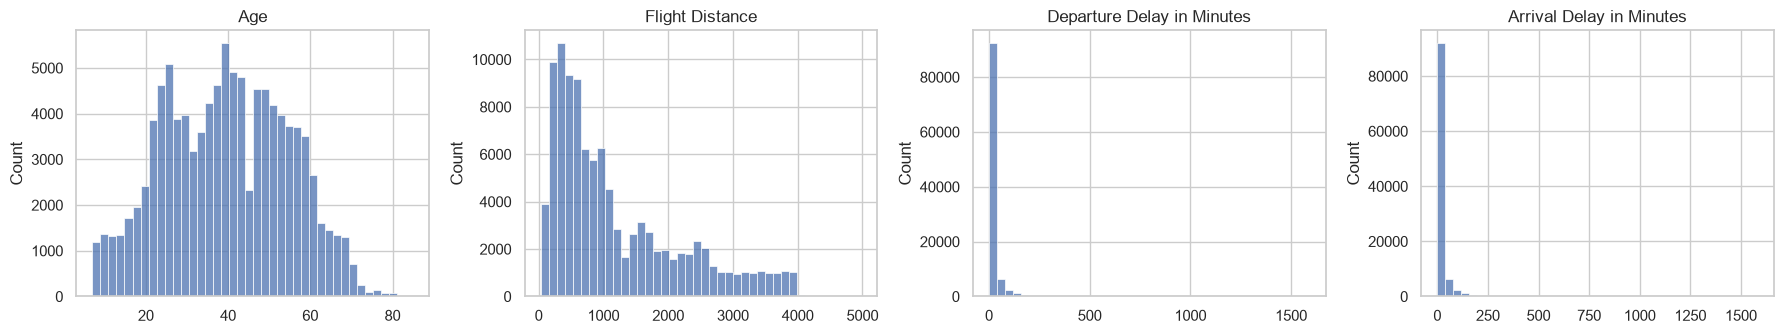

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(eda[c], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

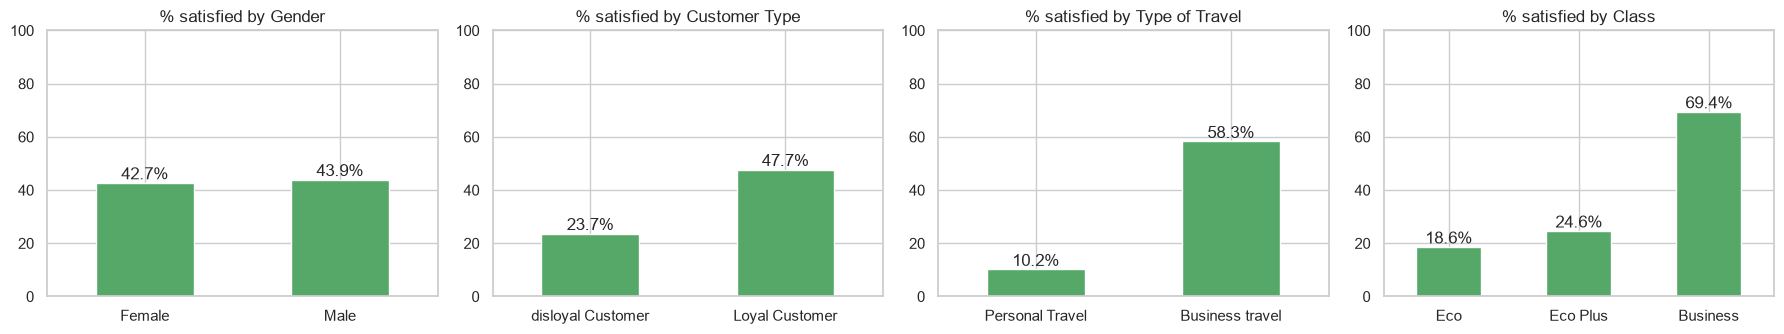

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, c in zip(axes, cat_cols):
    rate = eda.groupby(c)["sat_flag"].mean().mul(100).sort_values()
    rate.plot.bar(ax=ax, color="#55A868", rot=0)
    ax.bar_label(ax.containers[0], fmt="%.1f%%")
    ax.set_title(f"% satisfied by {c}")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

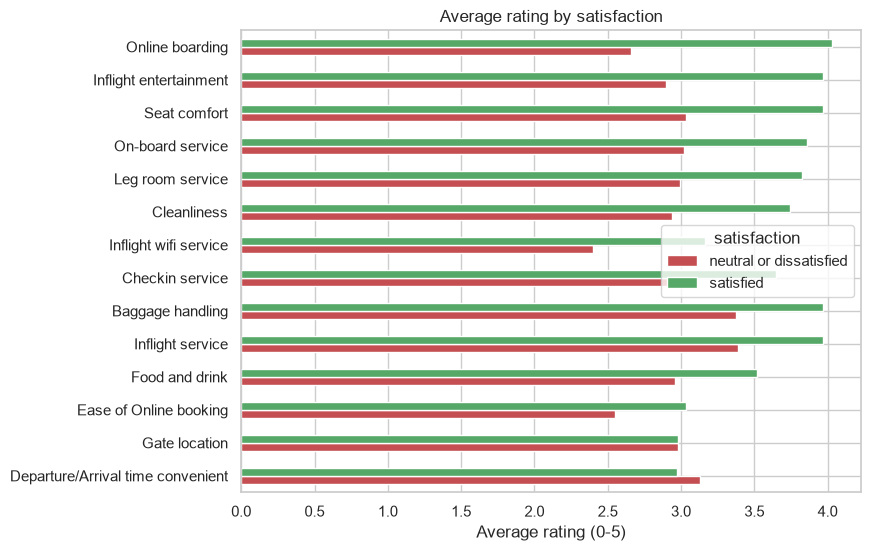

In [18]:
avg = eda.groupby("satisfaction")[rating_cols].mean().T
avg["gap"] = avg["satisfied"] - avg["neutral or dissatisfied"]
avg = avg.sort_values("gap")
avg[["neutral or dissatisfied", "satisfied"]].plot.barh(figsize=(8, 6), color=["#C44E52", "#55A868"])
plt.title("Average rating by satisfaction")
plt.xlabel("Average rating (0-5)")
plt.show()

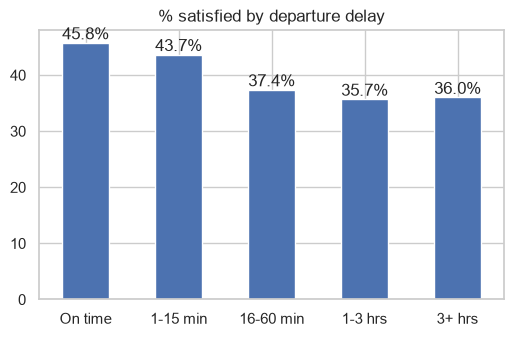

In [19]:
bins = [-1, 0, 15, 60, 180, np.inf]
labels = ["On time", "1-15 min", "16-60 min", "1-3 hrs", "3+ hrs"]
eda["delay_bucket"] = pd.cut(eda["Departure Delay in Minutes"], bins=bins, labels=labels)

rate = eda.groupby("delay_bucket", observed=True)["sat_flag"].mean().mul(100)
ax = rate.plot.bar(color="#4C72B0", rot=0, figsize=(6, 3.5))
ax.bar_label(ax.containers[0], fmt="%.1f%%")
ax.set_title("% satisfied by departure delay")
ax.set_xlabel("")
plt.show()

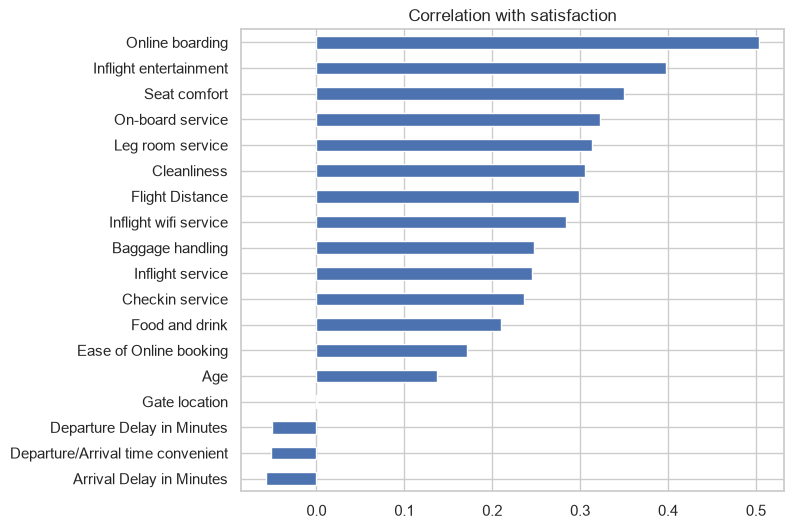

Departure vs Arrival delay correlation: 0.965


In [20]:
corr = eda[rating_cols + num_cols + ["sat_flag"]].corr()["sat_flag"].drop("sat_flag").sort_values()
corr.plot.barh(figsize=(7, 6), color="#4C72B0")
plt.title("Correlation with satisfaction")
plt.show()

print("Departure vs Arrival delay correlation:",
      round(eda[delay_cols].corr().iloc[0, 1], 3))

In [21]:
print("% satisfied by group")
for c in cat_cols:
    print(eda.groupby(c)["sat_flag"].mean().mul(100).round(1).to_dict())

print("\n% satisfied by departure delay")
print(eda.groupby("delay_bucket", observed=True)["sat_flag"].mean().mul(100).round(1).to_dict())

print("\nTop 5 rating gaps (satisfied minus not)")
print(avg["gap"].sort_values(ascending=False).head(5).round(2).to_dict())

print("\nBottom 3 rating gaps")
print(avg["gap"].sort_values().head(3).round(2).to_dict())

print("\nDelay correlation:", round(eda[delay_cols].corr().iloc[0, 1], 3))
print("Missing Arrival Delay:", eda["Arrival Delay in Minutes"].isna().sum())

% satisfied by group
{'Female': 42.7, 'Male': 43.9}
{'Loyal Customer': 47.7, 'disloyal Customer': 23.7}
{'Business travel': 58.3, 'Personal Travel': 10.2}
{'Business': 69.4, 'Eco': 18.6, 'Eco Plus': 24.6}

% satisfied by departure delay
{'On time': 45.8, '1-15 min': 43.7, '16-60 min': 37.4, '1-3 hrs': 35.7, '3+ hrs': 36.0}

Top 5 rating gaps (satisfied minus not)
{'Online boarding': 1.37, 'Inflight entertainment': 1.07, 'Seat comfort': 0.93, 'On-board service': 0.84, 'Leg room service': 0.83}

Bottom 3 rating gaps
{'Departure/Arrival time convenient': -0.16, 'Gate location': 0.0, 'Ease of Online booking': 0.48}

Delay correlation: 0.965
Missing Arrival Delay: 310


## 4. Five key insights

1. **Purpose of travel is the strongest split.** 58.3% of business travelers are satisfied vs only 10.2% of personal travelers, a gap of about 48 points.
2. **Class matters a lot.** Business class is 69.4% satisfied, Eco Plus 24.6% and Eco 18.6%. Economy passengers are the airline's biggest problem group.
3. **Loyal customers are twice as satisfied.** 47.7% of loyal customers are satisfied vs 23.7% of disloyal customers.
4. **Three services drive satisfaction most.** Online boarding (gap of 1.37 rating points between satisfied and unsatisfied passengers), inflight entertainment (1.07) and seat comfort (0.93) differ most. Gate location (0.00) and departure/arrival time convenience (-0.16) barely matter.
5. **Delays hurt, but less than expected, and gender doesn't matter.** Satisfaction falls from 45.8% for on-time flights to about 36-37% once delays pass 15 minutes, then flattens out. Gender is almost irrelevant (42.7% female vs 43.9% male).

**Caveat:** these are associations, not proof of cause. Travel type and class overlap (business travelers mostly fly business class), so the models will show which factors carry independent weight.

## 5. Data cleaning and missing values

In [27]:
known = train.dropna(subset=["Arrival Delay in Minutes"])
actual = known["Arrival Delay in Minutes"]

guesses = {
    "Own departure delay": known["Departure Delay in Minutes"],
    "Median": actual.median(),
    "Mean": actual.mean(),
}

rows = []
for name, guess in guesses.items():
    error = (actual - guess).abs().mean()
    rows.append([name, round(error, 2)])

pd.DataFrame(rows, columns=["Method", "Average error (minutes)"])

,Method,Average error (minutes)
0,Own departure delay,4.97
1,Median,15.18
2,Mean,20.58


**Missing values:** 310 rows (0.3%) had no `Arrival Delay in Minutes`. Three fill methods were tested on rows where the true value is known. Using the passenger's own departure delay had an average error of 4.97 minutes, against 15.18 for the median and 20.58 for the mean, so it is used. It needs no statistics learned from the data, so nothing can leak from test to train.

In [28]:
def clean(df):
    df = df.drop(columns=["Unnamed: 0", "id"]).copy()
    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(df["Departure Delay in Minutes"])
    return df

train_c = clean(train)
test_c = clean(test)

print("Missing in train:", train_c.isna().sum().sum())
print("Missing in test: ", test_c.isna().sum().sum())

Missing in train: 0
Missing in test:  0


In [29]:
zero_share = (train_c[rating_cols] == 0).mean() * 100
zero_share = zero_share.round(2).sort_values(ascending=False)

pd.DataFrame({"% of passengers with rating 0": zero_share})

,% of passengers with rating 0
Departure/Arrival time convenient,5.10
Ease of Online booking,4.32
Inflight wifi service,2.99
Online boarding,2.34
Leg room service,0.45
Food and drink,0.10
Cleanliness,0.01
Inflight entertainment,0.01
Gate location,0.00
Seat comfort,0.00


In [30]:
top_zero_cols = ["Departure/Arrival time convenient", "Ease of Online booking",
                 "Inflight wifi service", "Online boarding"]
is_satisfied = train_c["satisfaction"] == "satisfied"

rows = []
for col in top_zero_cols:
    zero = train_c[col] == 0
    rows.append([col,
                 round(is_satisfied[zero].mean() * 100, 1),
                 round(is_satisfied[~zero].mean() * 100, 1)])

pd.DataFrame(rows, columns=["Column", "% satisfied (rating 0)", "% satisfied (rating 1-5)"])

,Column,% satisfied (rating 0),% satisfied (rating 1-5)
0,Departure/Arrival time convenient,47.5,43.1
1,Ease of Online booking,66.4,42.3
2,Inflight wifi service,99.7,41.6
3,Online boarding,55.6,43.0


**Zero ratings:** 0 appears mostly in four columns (2% to 5% of passengers). It most likely means "service not used", and it is informative: passengers who rated Inflight wifi 0 are 99.7% satisfied vs 41.6% for the rest. Replacing 0 with an average would destroy that signal, so 0 values are kept as they are.

In [31]:
print("Duplicate rows:", train_c.duplicated().sum())

delays = train_c[["Departure Delay in Minutes", "Arrival Delay in Minutes"]]
delays.describe(percentiles=[0.5, 0.99]).loc[["50%", "99%", "max"]].round(0)

Duplicate rows: 0


,Departure Delay in Minutes,Arrival Delay in Minutes
50%,0.0,0.0
99%,182.0,184.0
max,1592.0,1584.0


## 6. Feature engineering and encoding

Categoricals are encoded as numbers (Class is ordered Eco < Eco Plus < Business). Four features are added: average service rating, count of 0 ratings, a delayed flag, and an age group.

In [32]:
def encode(df):
    df = df.copy()
    df["Gender"] = (df["Gender"] == "Male").astype(int)
    df["Customer Type"] = (df["Customer Type"] == "Loyal Customer").astype(int)
    df["Type of Travel"] = (df["Type of Travel"] == "Business travel").astype(int)
    df["Class"] = df["Class"].map({"Eco": 0, "Eco Plus": 1, "Business": 2})
    return df

train_e = encode(train_c)
test_e = encode(test_c)

train_e[cat_cols].head()

,Gender,Customer Type,Type of Travel,Class
0,1,1,0,1
1,1,0,1,2
2,0,1,1,2
3,0,1,1,2
4,1,1,1,2


In [33]:
def add_features(df):
    df = df.copy()
    df["avg_rating"] = df[rating_cols].mean(axis=1)
    df["zero_ratings"] = (df[rating_cols] == 0).sum(axis=1)
    df["is_delayed"] = (df["Departure Delay in Minutes"] > 15).astype(int)
    df["age_group"] = pd.cut(df["Age"], [0, 20, 30, 40, 50, 60, 120], labels=False)
    return df

train_f = add_features(train_e)
test_f = add_features(test_e)

train_f[["avg_rating", "zero_ratings", "is_delayed", "age_group"]].head()

,avg_rating,zero_ratings,is_delayed,age_group
0,3.857143,0,1,0
1,2.285714,0,0,1
2,3.714286,0,0,1
3,3.000000,0,0,1
4,3.500000,0,0,5


In [34]:
y_train = (train_f["satisfaction"] == "satisfied").astype(int)
y_test = (test_f["satisfaction"] == "satisfied").astype(int)

X_train = train_f.drop(columns="satisfaction")
X_test = test_f.drop(columns="satisfaction")

print("Number of features:", X_train.shape[1])
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Same columns in train and test:", list(X_train.columns) == list(X_test.columns))

Number of features: 26
X_train: (103904, 26) | X_test: (25976, 26)
Same columns in train and test: True


**Features:** 26 in total = 4 encoded categorical + 4 numeric + 14 service ratings + 4 engineered (`avg_rating`, `zero_ratings`, `is_delayed`, `age_group`).

## 7. Model training

Training data is split 80/20 into a training part and a validation part. Each of the six models is trained on the 80% and scored on the 20%. `test.csv` is not touched until the final evaluation. Logistic Regression and SVM are scaled inside a pipeline, so the scaler is fitted on training data only.


In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM": make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE)),
    "Naive Bayes": GaussianNB(),
}

list(models.keys())

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'XGBoost',
 'SVM',
 'Naive Bayes']

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
print("Training part:", X_tr.shape, "| Validation part:", X_val.shape)

scores = {}

def evaluate(name, model):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    else:
        auc = roc_auc_score(y_val, model.decision_function(X_val))
    scores[name] = {
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC-AUC": auc,
    }
    for metric, value in scores[name].items():
        print(f"{metric:10s}: {value:.4f}")

### 7.1 Logistic Regression

In [39]:
model = models["Logistic Regression"]
evaluate("Logistic Regression", model)
model

Accuracy  : 0.8899
Precision : 0.8716
Recall    : 0.8747
F1        : 0.8732
ROC-AUC   : 0.9561


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Gender','Customer Type','Age',...,'zero_ratings','is_delayed', 'age_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### 7.2 Decision Tree

In [40]:
model = models["Decision Tree"]
evaluate("Decision Tree", model)
model

Accuracy  : 0.9444
Precision : 0.9297
Recall    : 0.9429
F1        : 0.9363
ROC-AUC   : 0.9442


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

### 7.3 Random Forest

In [41]:
model = models["Random Forest"]
evaluate("Random Forest", model)
model

Accuracy  : 0.9631
Precision : 0.9692
Recall    : 0.9449
F1        : 0.9569
ROC-AUC   : 0.9943


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### 7.4 XGBoost

In [42]:
model = models["XGBoost"]
evaluate("XGBoost", model)
model

Accuracy  : 0.9625
Precision : 0.9642
Recall    : 0.9486
F1        : 0.9563
ROC-AUC   : 0.9953


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 7.5 SVM

In [43]:
model = models["SVM"]
evaluate("SVM", model)
model

Accuracy  : 0.9529
Precision : 0.9550
Recall    : 0.9354
F1        : 0.9451
ROC-AUC   : 0.9898


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Gender','Customer Type','Age',...,'zero_ratings','is_delayed', 'age_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### 7.6 Naive Bayes

In [44]:
model = models["Naive Bayes"]
evaluate("Naive Bayes", model)
model

Accuracy  : 0.8780
Precision : 0.8661
Recall    : 0.8498
F1        : 0.8578
ROC-AUC   : 0.9389


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[47103.,36020.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.57,0.43]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0009905
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](26,)","['Gender','Customer Type','Age',...,'zero_ratings','is_delayed', 'age_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,26
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 26)","[[ 0.49, 0.75,37.58,..., 0.1 , 0.25, 2.22], [ 0.5 , 0.9 ,41.76,..., 0.22, 0.19, 2.62]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 26)","[[ 0.25, 0.19,271.35,..., 0.16, 0.19, 2.48], [ 0.25, 0.09,163.34,..., 0.58, 0.15, 1.58]]"


## 8. Model comparison

In [45]:
comparison = pd.DataFrame(scores).T.sort_values("Accuracy", ascending=False)
print("Models scored:", len(comparison))
print("Best model:", comparison.index[0])
comparison.round(4)


Models scored: 6
Best model: Random Forest


,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.9631,0.9692,0.9449,0.9569,0.9943
XGBoost,0.9625,0.9642,0.9486,0.9563,0.9953
SVM,0.9529,0.9550,0.9354,0.9451,0.9898
Decision Tree,0.9444,0.9297,0.9429,0.9363,0.9442
Logistic Regression,0.8899,0.8716,0.8747,0.8732,0.9561
Naive Bayes,0.8780,0.8661,0.8498,0.8578,0.9389


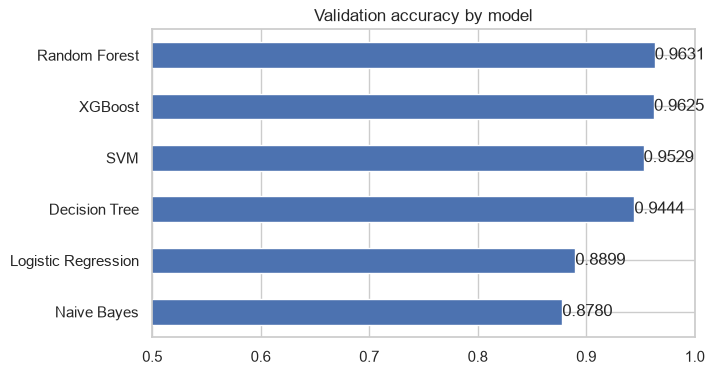

In [47]:
ax = comparison["Accuracy"].sort_values().plot.barh(figsize=(7, 4))
ax.bar_label(ax.containers[0], fmt="%.4f")
ax.set_xlim(0.5, 1.0)
ax.set_title("Validation accuracy by model")
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

for name in ["Random Forest", "XGBoost"]:
    acc = cross_val_score(models[name], X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name:14s} mean = {acc.mean():.4f} | std = {acc.std():.4f}")

Random Forest  mean = 0.9627 | std = 0.0015
XGBoost        mean = 0.9621 | std = 0.0015


**Model comparison**
- Tree ensembles are the strongest: Random Forest (96.31%) and XGBoost (96.25%) lead, followed by SVM (95.29%) and a single Decision Tree (94.44%).
- Logistic Regression (88.99%) and Naive Bayes (87.80%) are clearly weaker. Logistic Regression assumes a linear relationship and Naive Bayes assumes independent features, but the service ratings are correlated and satisfaction depends on interactions (for example travel type combined with class).
- Random Forest and XGBoost are statistically tied: 5-fold cross-validation gives 96.27% ± 0.15% vs 96.21% ± 0.15%, and the gap is smaller than the fold-to-fold variation.
- **Best model: Random Forest**, marginally ahead on both validation and cross-validation. It is taken forward for the confusion matrix and the final test evaluation.

## 9. Best model: final test evaluation and confusion matrix

The final Random Forest is trained on the full training set and scored once on `test.csv`, which no earlier step has used.

In [49]:
best_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision : {precision_score(y_test, test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, test_pred):.4f}")
print(f"F1        : {f1_score(y_test, test_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, test_proba):.4f}")

Accuracy  : 0.9630
Precision : 0.9728
Recall    : 0.9420
F1        : 0.9572
ROC-AUC   : 0.9940


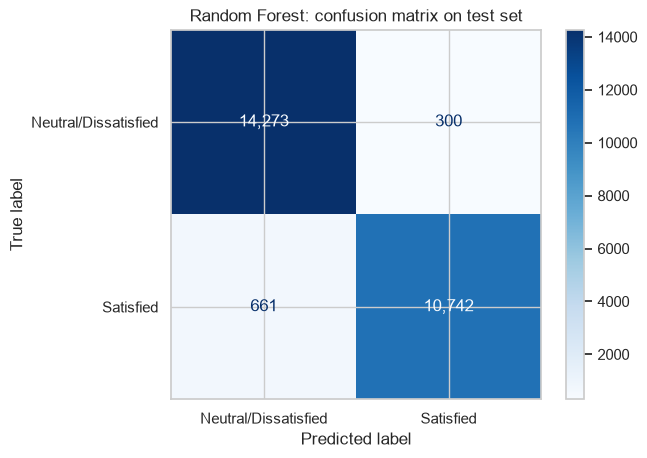

True negatives : 14,273
False positives: 300
False negatives: 661
True positives : 10,742


In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)
labels = ["Neutral/Dissatisfied", "Satisfied"]

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", values_format=",d")
plt.title("Random Forest: confusion matrix on test set")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives : {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives : {tp:,}")

**Confusion matrix interpretation (test set, 25,976 passengers)**

| | Predicted neutral/dissatisfied | Predicted satisfied |
|---|---|---|
| **Actually neutral/dissatisfied** | 14,273 (true negatives) | 300 (false positives) |
| **Actually satisfied** | 661 (false negatives) | 10,742 (true positives) |

- **961 of 25,976 predictions are wrong (3.7%)**, consistent with the 96.30% accuracy.
- **Precision 97.28%:** when the model says "satisfied", it is right 10,742 out of 11,042 times. Only 300 unhappy passengers are wrongly labelled satisfied.
- **Recall 94.20%:** it finds 10,742 of the 11,403 truly satisfied passengers and misses 661.
- **The model errs on the cautious side:** false negatives (661) are more than double the false positives (300). It is more likely to overlook a satisfied passenger than to call an unhappy one satisfied.
- **Which error matters more depends on use.** If the airline wants to find unhappy passengers to follow up with, the 300 false positives are the costly ones, since those passengers are treated as fine. If it wants to reward satisfied passengers, the 661 misses matter more.

## 10. Save the model

The trained model and the exact feature order are saved so the backend can load them.

In [51]:
import joblib
from pathlib import Path

out = Path("../ml/artifacts")
out.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, out / "random_forest.joblib", compress=3)
joblib.dump(list(X_train.columns), out / "feature_columns.joblib")

size_mb = (out / "random_forest.joblib").stat().st_size / 1e6
print(f"Saved model: {size_mb:.0f} MB")
print("Features saved:", len(X_train.columns))

Saved model: 29 MB
Features saved: 26
